# Lesson 21: Ensemble learning demonstration

This notebook demonstrates key concepts and tools for training ensemble models.

1. Baseline models
    - Logistic regression
    - Decision tree
2. Parallel ensembles
    - Voting ensemble
    - Bagging ensemble
    - Random forest
3. Serial (sequential) ensembles
    - AdaBoost
    - Gradient boosting
    - Stacking ensemble
4. Model comparison
    - Score comparison
    - Confusion matrix comparison
5. Model metric optimization
    - ROC_AUC optimized thresholds
    - F1 optimized thresholds

## Notebook set up

### Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_validate, TunedThresholdClassifierCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ensemble models
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)

### Dataset

In [2]:
# Generate synthetic dataset, similar to Lesson 20: classification but
# more challenging with: more features, redundant features, and noise
data = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_clusters_per_class=3,
    weights=[0.9, 0.1],
    flip_y=0.1,
    class_sep=0.5,
    random_state=315
)

# Create dataframe with feature columns
df = pd.DataFrame(data[0], columns=[f'feature_{i}' for i in range(data[0].shape[1])])
df['target'] = data[1]

# Split into train and test sets
train_df, test_df = train_test_split(df, random_state=315)
train_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
6850,2.056957,0.222830,-1.914398,1.095708,-2.389691,-1.113905,1.296463,-5.769138,-1.742394,-1.717438,...,0.903576,-1.730474,-0.211586,0.402758,-2.171021,1.242654,-0.993714,1.083335,1.735312,0
5856,1.776417,-3.711362,-0.042654,-4.450805,0.283605,0.062951,-2.952074,-4.635668,0.133406,-1.665485,...,-1.160329,1.273855,-2.754988,-5.904544,-0.580578,0.952436,-0.566598,-1.590927,0.632844,0
2483,-0.017753,1.031828,-2.485858,-0.667876,-1.021137,-0.692445,0.630700,2.300769,-1.097844,0.717599,...,-0.728046,0.328055,0.403882,1.735435,0.162798,-1.306485,-0.760256,0.780826,-1.476193,0
4915,-0.495843,2.895735,-2.537299,-2.609338,-0.875950,2.935914,3.253340,6.378967,-0.058042,-1.338881,...,-1.579209,1.383636,0.879382,2.941039,-0.171335,0.508342,-0.704955,1.260240,-2.110639,0
4598,0.899913,-0.241683,-1.206857,-4.108075,0.786454,-0.923499,-1.404900,-6.952240,-1.282080,-1.646648,...,3.731664,1.857395,-0.758554,4.081466,2.046172,0.938040,-0.088168,-0.283488,0.257320,0


### Helper functions

In [3]:
def mean_ci(values, z=1.96):
    '''Calculate the mean and 95% confidence interval for a given array of values.'''

    mean = values.mean()
    margin = z * values.std(ddof=1) / (len(values) ** 0.5)

    return mean, mean - margin, mean + margin

## 1. Baseline models

Scikit-learn [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) implementation

In [4]:
# Logistic regression baseline
lr_clf = LogisticRegression(random_state=315, max_iter=1000, class_weight='balanced')

lr_scores = cross_validate(
    lr_clf,
    train_df.drop('target', axis=1),
    train_df['target'],
    cv=7,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

lr_auc = lr_scores['test_roc_auc']
lr_f1 = lr_scores['test_f1']

lr_auc_mean, lr_auc_low, lr_auc_high = mean_ci(lr_auc)
lr_f1_mean, lr_f1_low, lr_f1_high = mean_ci(lr_f1)
print(
    f'Logistic Regression - AUC: {lr_auc_mean:.3f} (95% CI: {lr_auc_low:.3f}, {lr_auc_high:.3f}), '
    f'F1: {lr_f1_mean:.3f} (95% CI: {lr_f1_low:.3f}, {lr_f1_high:.3f})'
)

lr_clf.fit(train_df.drop('target', axis=1), train_df['target'])
lr_pred = lr_clf.predict(test_df.drop('target', axis=1))

Logistic Regression - AUC: 0.663 (95% CI: 0.642, 0.683), F1: 0.305 (95% CI: 0.291, 0.318)


Scikit-learn [Decision Tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) implementation

In [5]:
# Decision tree baseline
dt_clf = DecisionTreeClassifier(random_state=315, class_weight='balanced')

dt_scores = cross_validate(
    dt_clf,
    train_df.drop('target', axis=1),
    train_df['target'],
    cv=7,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

dt_auc = dt_scores['test_roc_auc']
dt_f1 = dt_scores['test_f1']

dt_auc_mean, dt_auc_low, dt_auc_high = mean_ci(dt_auc)
dt_f1_mean, dt_f1_low, dt_f1_high = mean_ci(dt_f1)
print(
    f'Decision Tree - AUC: {dt_auc_mean:.3f} (95% CI: {dt_auc_low:.3f}, {dt_auc_high:.3f}), '
    f'F1: {dt_f1_mean:.3f} (95% CI: {dt_f1_low:.3f}, {dt_f1_high:.3f})'
)

dt_clf.fit(train_df.drop('target', axis=1), train_df['target'])
dt_pred = dt_clf.predict(test_df.drop('target', axis=1))

Decision Tree - AUC: 0.600 (95% CI: 0.588, 0.612), F1: 0.307 (95% CI: 0.287, 0.327)


## 2. Parallel ensembles

### 2.1. Voting ensemble

Combines predictions from multiple independent models by majority vote (hard voting) or by averaging predicted probabilities (soft voting).

Scikit-learn [Voting Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html) implementation

In [6]:
# Create voting classifier with soft voting
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=315, max_iter=1000, class_weight='balanced')),
        ('dt', DecisionTreeClassifier(random_state=315, class_weight='balanced')),
        ('svm', CalibratedClassifierCV(SVC(random_state=315, class_weight='balanced'), ensemble=False))
    ],
    voting='soft'
)

voting_scores = cross_validate(
    voting_clf,
    train_df.drop('target', axis=1),
    train_df['target'],
    cv=7,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

voting_auc = voting_scores['test_roc_auc']
voting_f1 = voting_scores['test_f1']

voting_auc_mean, voting_auc_low, voting_auc_high = mean_ci(voting_auc)
voting_f1_mean, voting_f1_low, voting_f1_high = mean_ci(voting_f1)
print(
    f'Voting - AUC: {voting_auc_mean:.3f} (95% CI: {voting_auc_low:.3f}, {voting_auc_high:.3f}), '
    f'F1: {voting_f1_mean:.3f} (95% CI: {voting_f1_low:.3f}, {voting_f1_high:.3f})'
)

voting_clf.fit(train_df.drop('target', axis=1), train_df['target'])
voting_pred = voting_clf.predict(test_df.drop('target', axis=1))

Voting - AUC: 0.764 (95% CI: 0.752, 0.776), F1: 0.360 (95% CI: 0.343, 0.377)


### 2.2. Bagging ensemble

Trains multiple instances of the same model on different random subsets of the training data (with replacement), then averages their predictions to reduce variance.

Scikit-learn [Bagging Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) implementation

In [7]:
# Create bagging classifier with decision trees
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=315, class_weight='balanced'),
    n_estimators=100,
    random_state=315,
    oob_score=True
)

bagging_scores = cross_validate(
    bagging_clf,
    train_df.drop('target', axis=1),
    train_df['target'],
    cv=7,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

bagging_auc = bagging_scores['test_roc_auc']
bagging_f1 = bagging_scores['test_f1']

bagging_auc_mean, bagging_auc_low, bagging_auc_high = mean_ci(bagging_auc)
bagging_f1_mean, bagging_f1_low, bagging_f1_high = mean_ci(bagging_f1)
print(
    f'Bagging - AUC: {bagging_auc_mean:.3f} (95% CI: {bagging_auc_low:.3f}, {bagging_auc_high:.3f}), '
    f'F1: {bagging_f1_mean:.3f} (95% CI: {bagging_f1_low:.3f}, {bagging_f1_high:.3f})'
)

bagging_clf.fit(train_df.drop('target', axis=1), train_df['target'])
bagging_pred = bagging_clf.predict(test_df.drop('target', axis=1))

Bagging - AUC: 0.783 (95% CI: 0.764, 0.802), F1: 0.244 (95% CI: 0.217, 0.271)


### 2.3. Random forest

An extension of bagging that uses decision trees as base models and introduces additional randomness by considering only a random subset of features at each split.

Scikit-learn [Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) implementation

In [12]:
# Create random forest classifier
rf_clf = RandomForestClassifier(
    n_estimators=500,
    random_state=315,
    oob_score=True,
    class_weight='balanced'
)

rf_scores = cross_validate(
    rf_clf,
    train_df.drop('target', axis=1),
    train_df['target'],
    cv=7,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

rf_auc = rf_scores['test_roc_auc']
rf_f1 = rf_scores['test_f1']

rf_auc_mean, rf_auc_low, rf_auc_high = mean_ci(rf_auc)
rf_f1_mean, rf_f1_low, rf_f1_high = mean_ci(rf_f1)
print(
    f'Random Forest - AUC: {rf_auc_mean:.3f} (95% CI: {rf_auc_low:.3f}, {rf_auc_high:.3f}), '
    f'F1: {rf_f1_mean:.3f} (95% CI: {rf_f1_low:.3f}, {rf_f1_high:.3f})'
)

rf_clf.fit(train_df.drop('target', axis=1), train_df['target'])
rf_pred = rf_clf.predict(test_df.drop('target', axis=1))

Random Forest - AUC: 0.799 (95% CI: 0.780, 0.818), F1: 0.444 (95% CI: 0.404, 0.484)


## 3. Serial (sequential) ensembles

### 3.1. AdaBoost

Sequentially trains weak learners where each new model focuses more on the examples that previous models misclassified by adjusting sample weights.

Scikit-learn [AdaBoost Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) implementation

In [9]:
# Create AdaBoost classifier
adaboost_clf = AdaBoostClassifier(
    n_estimators=100,
    random_state=315
)

adaboost_scores = cross_validate(
    adaboost_clf,
    train_df.drop('target', axis=1),
    train_df['target'],
    cv=7,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

adaboost_auc = adaboost_scores['test_roc_auc']
adaboost_f1 = adaboost_scores['test_f1']

adaboost_auc_mean, adaboost_auc_low, adaboost_auc_high = mean_ci(adaboost_auc)
adaboost_f1_mean, adaboost_f1_low, adaboost_f1_high = mean_ci(adaboost_f1)
print(
    f'AdaBoost - AUC: {adaboost_auc_mean:.3f} (95% CI: {adaboost_auc_low:.3f}, {adaboost_auc_high:.3f}), '
    f'F1: {adaboost_f1_mean:.3f} (95% CI: {adaboost_f1_low:.3f}, {adaboost_f1_high:.3f})'
)

adaboost_clf.fit(train_df.drop('target', axis=1), train_df['target'])
adaboost_pred = adaboost_clf.predict(test_df.drop('target', axis=1))

AdaBoost - AUC: 0.684 (95% CI: 0.661, 0.707), F1: 0.086 (95% CI: 0.068, 0.104)


### 3.2. Gradient boosting

Builds models sequentially where each new model is trained to predict the residual errors of the previous ensemble, using gradient descent to minimize a loss function.

Scikit-learn [Gradient Boosting Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) implementation

In [10]:
# Create Gradient Boosting classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=315
)

gb_scores = cross_validate(
    gb_clf,
    train_df.drop('target', axis=1),
    train_df['target'],
    cv=7,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

gb_auc = gb_scores['test_roc_auc']
gb_f1 = gb_scores['test_f1']

gb_auc_mean, gb_auc_low, gb_auc_high = mean_ci(gb_auc)
gb_f1_mean, gb_f1_low, gb_f1_high = mean_ci(gb_f1)
print(
    f'Gradient Boosting - AUC: {gb_auc_mean:.3f} (95% CI: {gb_auc_low:.3f}, {gb_auc_high:.3f}), '
    f'F1: {gb_f1_mean:.3f} (95% CI: {gb_f1_low:.3f}, {gb_f1_high:.3f})'
)

gb_clf.fit(train_df.drop('target', axis=1), train_df['target'])
gb_pred = gb_clf.predict(test_df.drop('target', axis=1))

Gradient Boosting - AUC: 0.736 (95% CI: 0.718, 0.755), F1: 0.226 (95% CI: 0.202, 0.250)


### 3.3. Stacking ensemble

Trains multiple diverse base models, then uses their predictions as input features for a meta-model that learns how to best combine them.

Scikit-learn [Stacking Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html) implementation

In [13]:
# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, random_state=315, class_weight='balanced')),
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=315, class_weight='balanced')),
        ('svm', CalibratedClassifierCV(SVC(random_state=315, class_weight='balanced'), ensemble=False))
    ],
    final_estimator=LogisticRegression(random_state=315, max_iter=1000, class_weight='balanced'),
    cv=7
)

stacking_scores = cross_validate(
    stacking_clf,
    train_df.drop('target', axis=1),
    train_df['target'],
    cv=7,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

stacking_auc = stacking_scores['test_roc_auc']
stacking_f1 = stacking_scores['test_f1']

stacking_auc_mean, stacking_auc_low, stacking_auc_high = mean_ci(stacking_auc)
stacking_f1_mean, stacking_f1_low, stacking_f1_high = mean_ci(stacking_f1)
print(
    f'Stacking - AUC: {stacking_auc_mean:.3f} (95% CI: {stacking_auc_low:.3f}, {stacking_auc_high:.3f}), '
    f'F1: {stacking_f1_mean:.3f} (95% CI: {stacking_f1_low:.3f}, {stacking_f1_high:.3f})'
)

stacking_clf.fit(train_df.drop('target', axis=1), train_df['target'])
stacking_pred = stacking_clf.predict(test_df.drop('target', axis=1))

Stacking - AUC: 0.811 (95% CI: 0.794, 0.828), F1: 0.521 (95% CI: 0.507, 0.534)


## 4. Model comparison

In [14]:
# Collect results
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Voting', 'Bagging', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'Stacking'],
    'AUC': [lr_auc, dt_auc, voting_auc, bagging_auc, rf_auc, adaboost_auc, gb_auc, stacking_auc],
    'F1': [lr_f1, dt_f1, voting_f1, bagging_f1, rf_f1, adaboost_f1, gb_f1, stacking_f1],
    'Predictions': [lr_pred, dt_pred, voting_pred, bagging_pred, rf_pred, adaboost_pred, gb_pred, stacking_pred]
}

results_df = pd.DataFrame({
    'Model': results['Model'],
    'AUC Mean': [mean_ci(auc)[0] for auc in results['AUC']],
    'AUC 95% CI Low': [mean_ci(auc)[1] for auc in results['AUC']],
    'AUC 95% CI High': [mean_ci(auc)[2] for auc in results['AUC']],
    'F1 Mean': [mean_ci(f1)[0] for f1 in results['F1']],
    'F1 95% CI Low': [mean_ci(f1)[1] for f1 in results['F1']],
    'F1 95% CI High': [mean_ci(f1)[2] for f1 in results['F1']]
})

results_df

,Model,AUC Mean,AUC 95% CI Low,AUC 95% CI High,F1 Mean,F1 95% CI Low,F1 95% CI High
0,Logistic Regression,0.662758,0.642092,0.683424,0.304572,0.291414,0.317729
1,Decision Tree,0.599774,0.587684,0.611864,0.307292,0.287241,0.327343
2,Voting,0.764078,0.752256,0.775899,0.360355,0.343349,0.377361
3,Bagging,0.783047,0.763948,0.802146,0.243632,0.216746,0.270519
4,Random Forest,0.798929,0.780129,0.817729,0.444362,0.404471,0.484254
5,AdaBoost,0.683823,0.661132,0.706513,0.085703,0.067820,0.103587
6,Gradient Boosting,0.736354,0.717980,0.754728,0.225941,0.201503,0.250379
7,Stacking,0.811252,0.794148,0.828356,0.520599,0.506728,0.534470


### 4.1. Score comparison

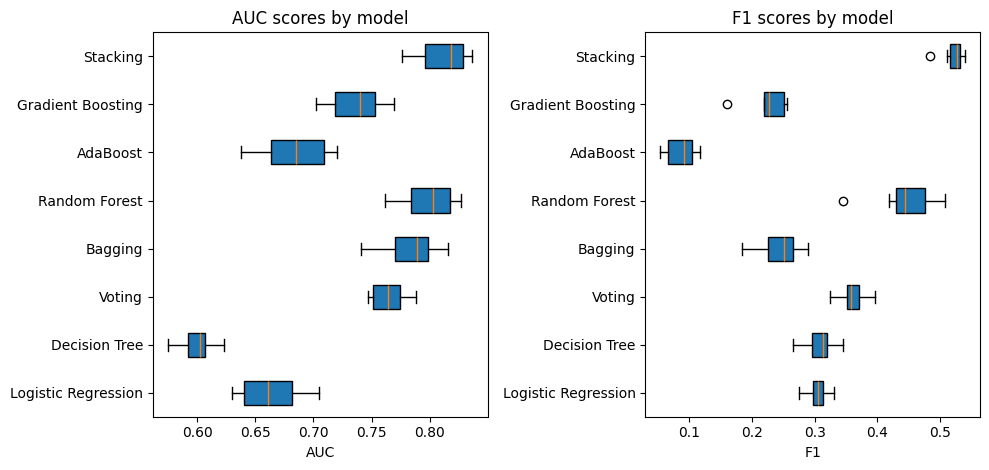

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4.8))

# AUC boxplot
auc_data = [auc for auc in results['AUC']]

axes[0].boxplot(
    auc_data,
    tick_labels=results['Model'],
    patch_artist=True,
    vert=False
)

axes[0].set_title('AUC scores by model')
axes[0].set_xlabel('AUC')

# F1 boxplot
f1_data = [f1 for f1 in results['F1']]

axes[1].boxplot(
    f1_data,
    tick_labels=results['Model'],
    patch_artist=True,
    vert=False
)

axes[1].set_title('F1 scores by model')
axes[1].set_xlabel('F1')

plt.tight_layout()
plt.show()

### 4.2. Confusion matrix comparison

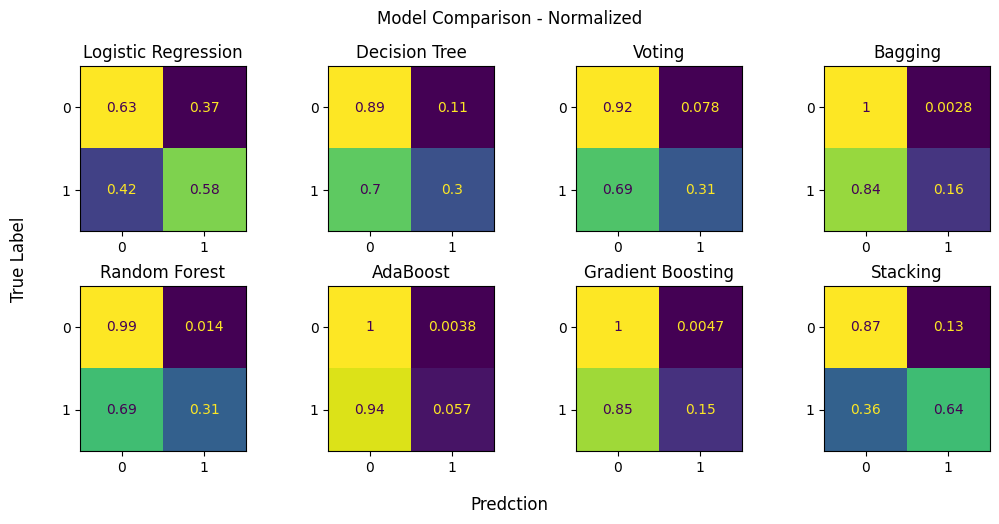

In [16]:
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.6, nrows*2.6))
axes = axes.flatten()

fig.suptitle('Model Comparison - Normalized')
fig.supylabel('True Label')
fig.supxlabel('Predction')

for i, (model_name, pred) in enumerate(zip(results['Model'], results['Predictions'])):

    disp = ConfusionMatrixDisplay.from_predictions(
        test_df['target'],
        pred,
        normalize='true',
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

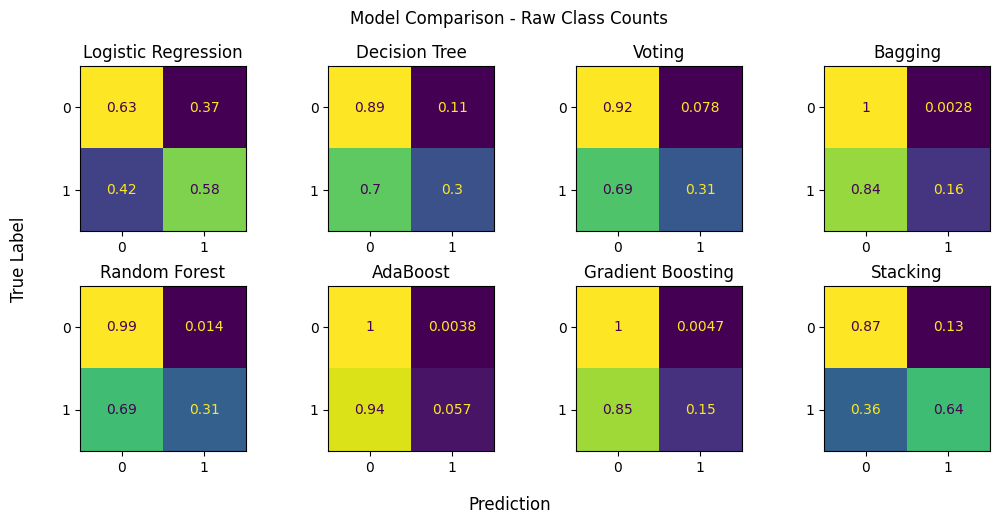

In [17]:
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.6, nrows*2.6))
axes = axes.flatten()

fig.suptitle('Model Comparison - Raw Class Counts')
fig.supylabel('True Label')
fig.supxlabel('Prediction')

for i, (model_name, pred) in enumerate(zip(results['Model'], results['Predictions'])):

    disp = ConfusionMatrixDisplay.from_predictions(
        test_df['target'],
        pred,
        ax=axes[i],
        colorbar=False,
        normalize='true'
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Model metric optimization

In [18]:
num_samples = 1000

### 5.1. ROC_AUC optimized thresholds

This section uses a threshold tuner to search for a cutoff that improves the model's decision boundary. The key point is that the tuner evaluates candidate thresholds after converting the predicted probabilities into binary labels. That means the optimization is no longer the usual threshold-independent ROC AUC on the raw probability scores. Instead, it becomes a search over thresholds where the score can change depending on the cutoff being used.

In other words, this is a threshold-tuning exercise, not the standard ROC AUC calculation you would normally use for ranking quality. Outside of a threshold tuner, ROC AUC is usually computed from the predicted probabilities directly and is not tied to a specific cutoff.

In [19]:
model_thres_results = {}

for model in [lr_clf, dt_clf, voting_clf, bagging_clf, rf_clf, adaboost_clf, gb_clf, stacking_clf]:
    TunedThreshCV = TunedThresholdClassifierCV(estimator=model, scoring='roc_auc') 
    TunedThreshCV.fit(X=train_df.drop('target', axis=1)[:num_samples], y=train_df['target'][:num_samples])
    
    model_thres_results[model] = TunedThreshCV.best_threshold_
    print(f'{type(model).__name__} new threshold: {TunedThreshCV.best_threshold_:.3f}')

LogisticRegression new threshold: 0.476
DecisionTreeClassifier new threshold: 0.010
VotingClassifier new threshold: 0.224
BaggingClassifier new threshold: 0.132
RandomForestClassifier new threshold: 0.268
AdaBoostClassifier new threshold: 0.449
GradientBoostingClassifier new threshold: 0.126
StackingClassifier new threshold: 0.456


In [20]:
preds = {}

for model_name, model in zip(results['Model'], [lr_clf, dt_clf, voting_clf, bagging_clf, rf_clf, adaboost_clf, gb_clf, stacking_clf]):
    print("roc_auc optimized - ", model_name, round(model_thres_results[model], 3))

    preds[model] = model.predict_proba(test_df.drop(['target'][:num_samples], axis=1))[:, 1] > model_thres_results[model]

roc_auc optimized -  Logistic Regression 0.476
roc_auc optimized -  Decision Tree 0.01
roc_auc optimized -  Voting 0.224
roc_auc optimized -  Bagging 0.132
roc_auc optimized -  Random Forest 0.268
roc_auc optimized -  AdaBoost 0.449
roc_auc optimized -  Gradient Boosting 0.126
roc_auc optimized -  Stacking 0.456


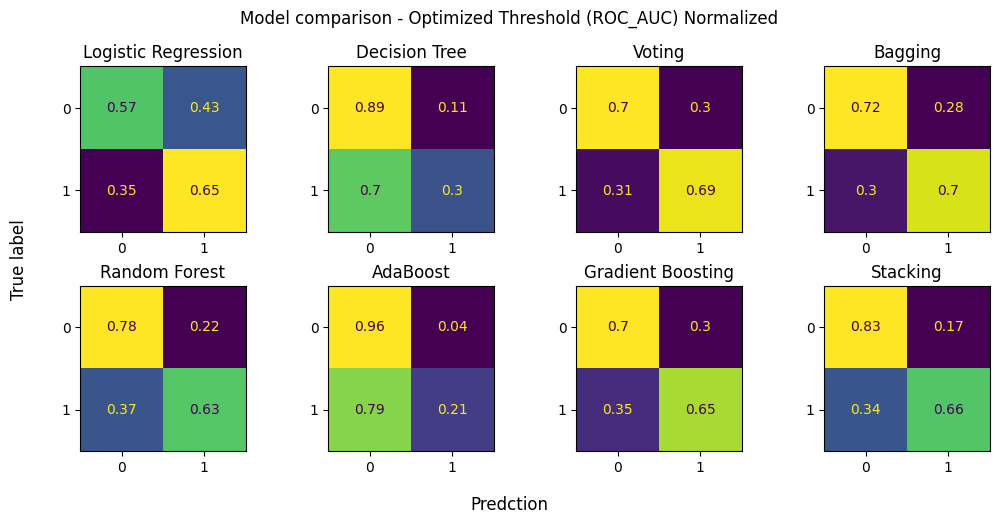

In [21]:
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.6, nrows*2.6))
axes = axes.flatten()

fig.suptitle('Model comparison - Optimized Threshold (ROC_AUC) Normalized')
fig.supylabel('True label')
fig.supxlabel('Predction')

for i, (model_name, model) in enumerate(zip(results['Model'], [lr_clf, dt_clf, voting_clf, bagging_clf, rf_clf, adaboost_clf, gb_clf, stacking_clf])):

    disp = ConfusionMatrixDisplay.from_predictions(
        test_df['target'],
        preds[model],
        normalize='true',
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

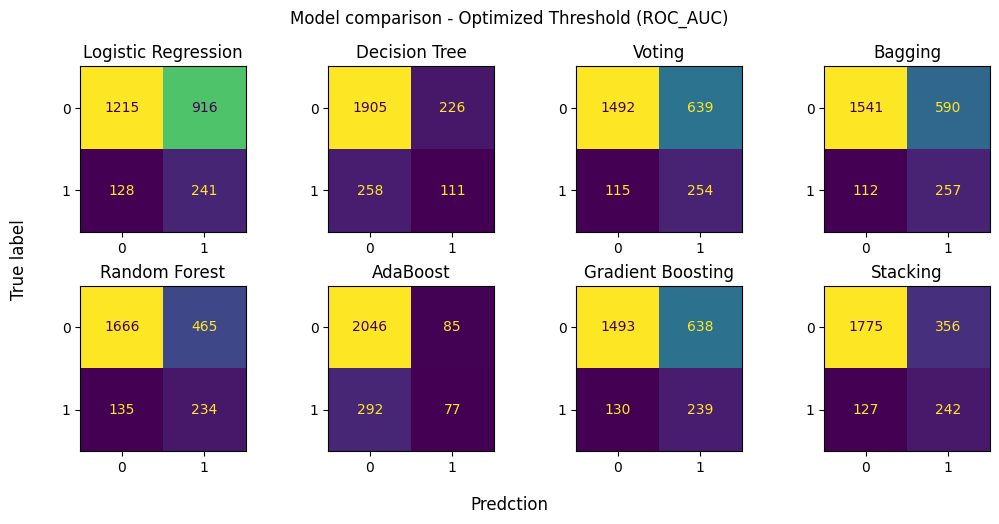

In [ ]:
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.6, nrows*2.6))
axes = axes.flatten()

fig.suptitle('Model comparison - Optimized Threshold (ROC_AUC)')
fig.supylabel('True label')
fig.supxlabel('prediction')

for i, (model_name, model) in enumerate(zip(results['Model'], [lr_clf, dt_clf, voting_clf, bagging_clf, rf_clf, adaboost_clf, gb_clf, stacking_clf])):

    disp = ConfusionMatrixDisplay.from_predictions(
        test_df['target'],
        preds[model],
        #normalize='true',
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### 5.2. F1 optimized thresholds

In [23]:
model_thres_results = {}

for model in [lr_clf, dt_clf, voting_clf, bagging_clf, rf_clf, adaboost_clf, gb_clf, stacking_clf]:
    TunedThreshCV = TunedThresholdClassifierCV(estimator=model, scoring='f1') 
    TunedThreshCV.fit(X=train_df.drop('target', axis=1)[:num_samples], y=train_df['target'][:num_samples])
    
    model_thres_results[model] = TunedThreshCV.best_threshold_
    print(f'{type(model).__name__} new threshold: {TunedThreshCV.best_threshold_:.3f}')

LogisticRegression new threshold: 0.485
DecisionTreeClassifier new threshold: 0.000
VotingClassifier new threshold: 0.224
BaggingClassifier new threshold: 0.209
RandomForestClassifier new threshold: 0.268
AdaBoostClassifier new threshold: 0.449
GradientBoostingClassifier new threshold: 0.126
StackingClassifier new threshold: 0.590


In [24]:
preds = {}
for model_name, model in zip(results['Model'], [lr_clf, dt_clf, voting_clf, bagging_clf, rf_clf, adaboost_clf, gb_clf, stacking_clf]):
    print("f1 optimized - ", model_name, round(model_thres_results[model], 3))

    preds[model] = model.predict_proba(test_df.drop(['target'][:num_samples], axis=1))[:, 1] > model_thres_results[model]

f1 optimized -  Logistic Regression 0.485
f1 optimized -  Decision Tree 0.0
f1 optimized -  Voting 0.224
f1 optimized -  Bagging 0.209
f1 optimized -  Random Forest 0.268
f1 optimized -  AdaBoost 0.449
f1 optimized -  Gradient Boosting 0.126
f1 optimized -  Stacking 0.59


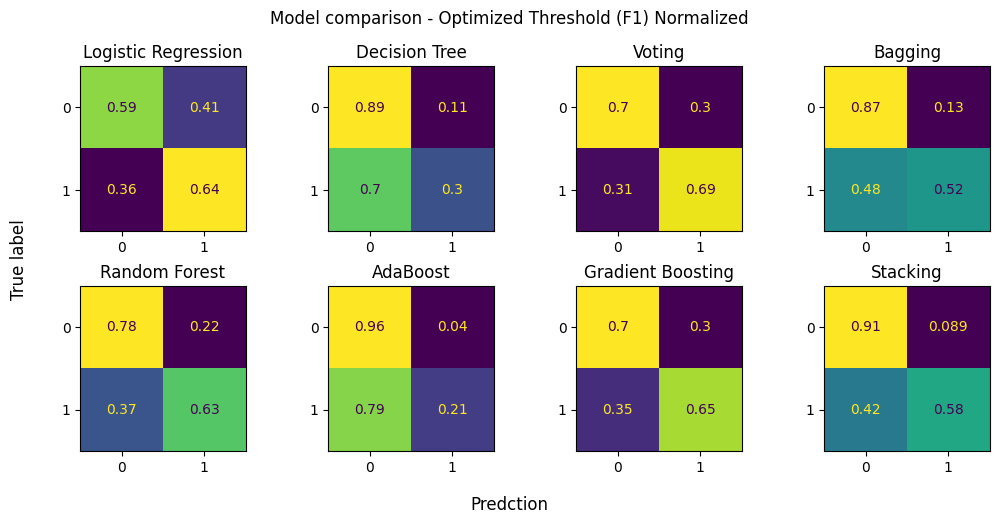

In [25]:
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.6, nrows*2.6))
axes = axes.flatten()

fig.suptitle('Model comparison - Optimized Threshold (F1) Normalized')
fig.supylabel('True label')
fig.supxlabel('Predction')

for i, (model_name, model) in enumerate(zip(results['Model'], [lr_clf, dt_clf, voting_clf, bagging_clf, rf_clf, adaboost_clf, gb_clf, stacking_clf])):

    disp = ConfusionMatrixDisplay.from_predictions(
        test_df['target'],
        preds[model],
        normalize='true',
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

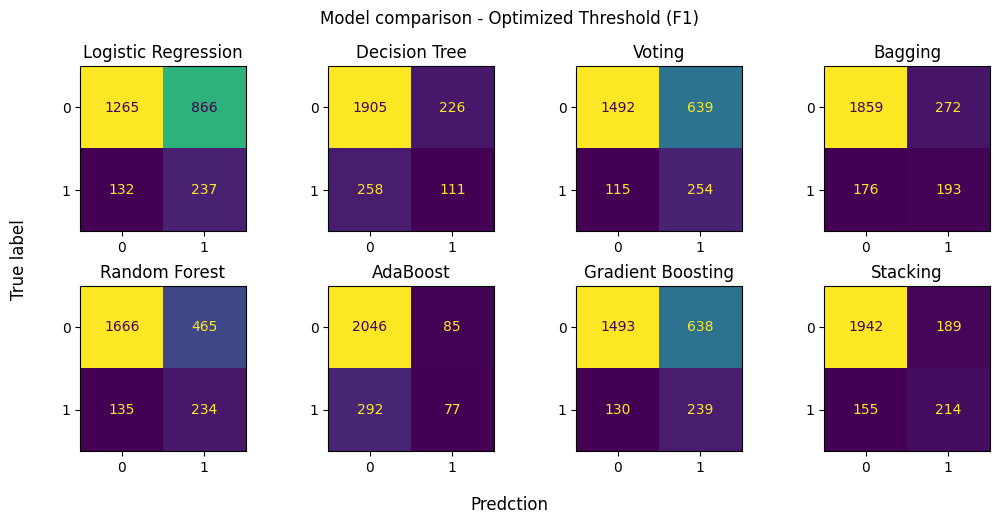

In [26]:
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.6, nrows*2.6))
axes = axes.flatten()

fig.suptitle('Model comparison - Optimized Threshold (F1)')
fig.supylabel('True label')
fig.supxlabel('Predction')

for i, (model_name, model) in enumerate(zip(results['Model'], [lr_clf, dt_clf, voting_clf, bagging_clf, rf_clf, adaboost_clf, gb_clf, stacking_clf])):

    disp = ConfusionMatrixDisplay.from_predictions(
        test_df['target'],
        preds[model],
        #normalize='true',
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()